# 1. Importing Libraries

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder # used to import categorical values
from imblearn.over_sampling import SMOTE # handles imbalanced dataset in ML
from sklearn.model_selection import train_test_split,cross_val_score # cross validation perform training and testting on different splits of dataset
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.metrics import roc_curve, roc_auc_score
import pickle

# 2. Loading Dataset

In [73]:
#loadinf data to pandas dataframe
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [74]:
df.shape

(7043, 21)

In [75]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [76]:
# we are not able to view all the columns so to solve that,
pd.set_option('display.max_columns',None)

In [77]:
df.head() # Now all the columns are visible

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# 3. Data Cleaning

In [79]:
# most of the data columns which we have are categorical data
# Senior citizen(Yes or no : 1 or 0),tenure,Monthly chareges and TotalCharges are the only numerical values
# here we can see that TotalCharges was supposed to be a float but its object here
# few more things :
# Customer id is of no use so delete it

In [80]:
df=df.drop(columns=["customerID"])

In [81]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [82]:
numerical_features_list=['tenure','MonthlyCharges','TotalCharges']

#printing all the unique values in the columns:
for col in df.columns:
  if col not in numerical_features_list:      #done because we don't need unique values for columns which are numerical
    print(col,df[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [83]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [84]:
df[df['TotalCharges']==' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [85]:
len(df[df['TotalCharges']==' ']) #from here we get that there are 11 rows which has this type of data

11

In [86]:
df['TotalCharges']=df['TotalCharges'].replace({' ':'0.0'})

In [87]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [88]:
df.info()    # Now finally after replacing and changing datatype , TotalCharges has an datatype of FLOAT

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [89]:
# Checking Column Distribution of Target Feature
print(df['Churn'].value_counts())  # We can clearly see that the distribution is IMBALANCED . So either Downsampling or Upsampling needs to be done

Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Insights**

1.Removed Customer ID as it was'nt required

2.No missing value in the dataset

3.Missing values in Total charges was replaced with 0

4.Class Imbalanced identified in the dataset

# 4. Exploratory Data Analysis (EDA)

In [90]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Numerical Features -> Analysis

understanding the distribution of data

In [91]:
def plot_histogram(df,column_name):
  plt.figure(figsize=(5,3))
  sns.histplot(df[column_name],kde=True)  # kde would plot the curve around cols
  plt.title(f"Distribution of {column_name}")

  #calculate mean and median of the cols
  col_mean=df[column_name].mean()
  col_median=df[column_name].median()

  #add vertical lines for mean and median
  plt.axvline(col_mean,color='red',linestyle="--",label="mean")
  plt.axvline(col_median,color='green',linestyle="--",label="median")

  plt.legend()

  plt.show()

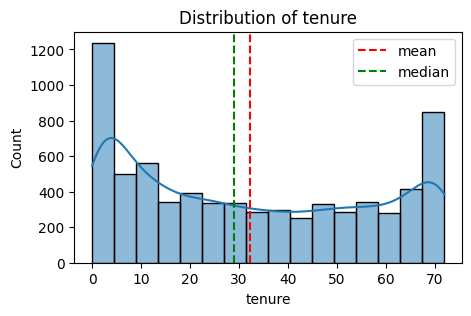

In [92]:
plot_histogram(df,"tenure")

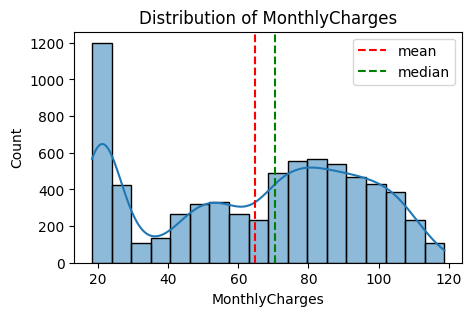

In [93]:
plot_histogram(df,"MonthlyCharges")

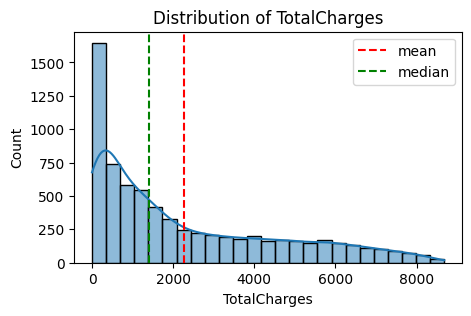

In [94]:
plot_histogram(df,"TotalCharges")   # THIS DISTRIBUTION IS SKEWED

**Box plot for Numerical features**

In [95]:
def plot_boxplot(df,column_name):
  plt.figure(figsize=(5,3))
  sns.boxplot(y=df[column_name])
  plt.title(f"BoxPlot of {column_name}")
  plt.ylabel(column_name)
  plt.show()

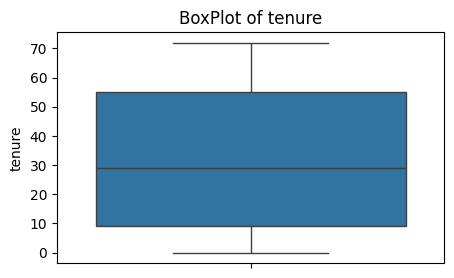

In [96]:
plot_boxplot(df,"tenure")

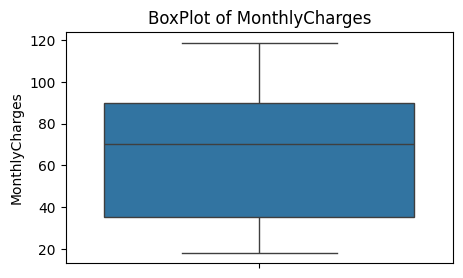

In [97]:
plot_boxplot(df,"MonthlyCharges")

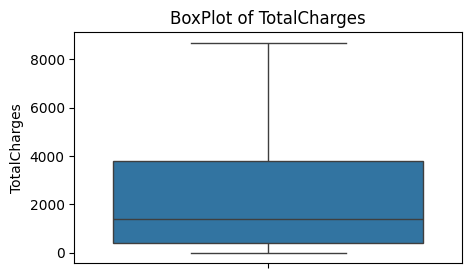

In [98]:
plot_boxplot(df,"TotalCharges")

Correlation Heatmap between numerical values

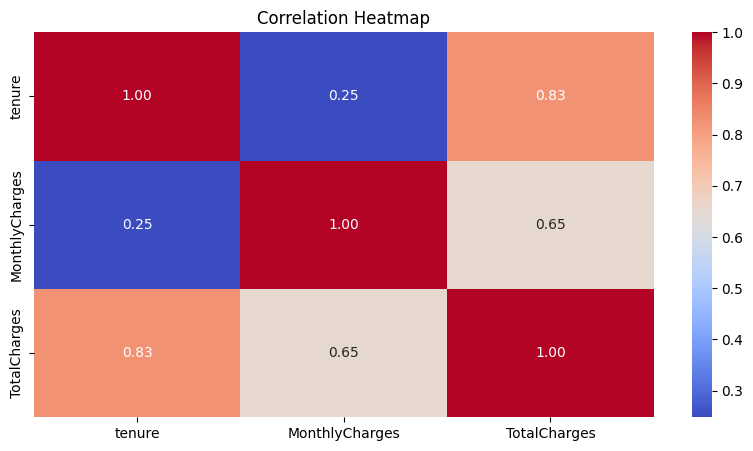

In [99]:
#Correlation matrix -> Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#here we can see that the tenure and totalcharges have a high correlation , we can drop one of these . But for the meanwhile we are not droping anyone of it .

categrorical feature -> anlaysis

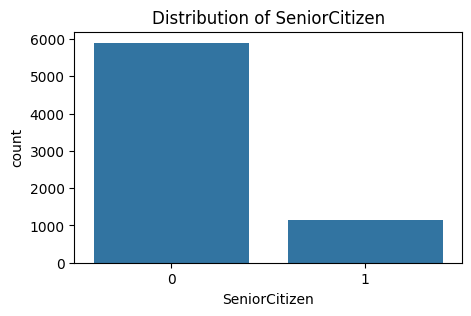

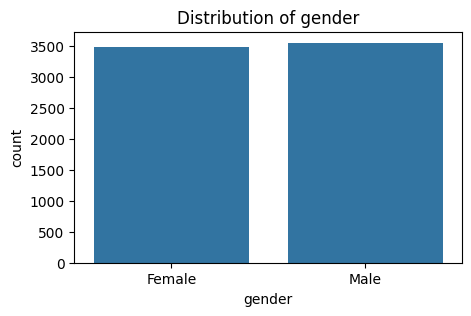

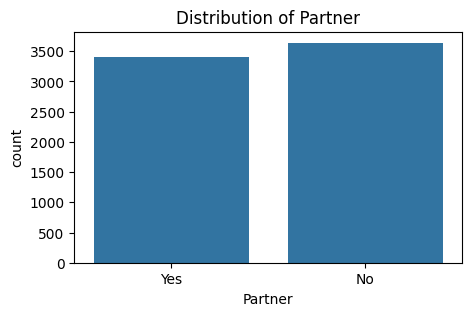

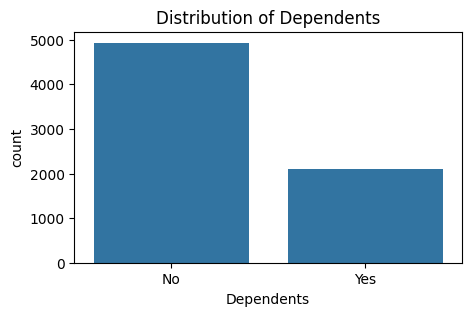

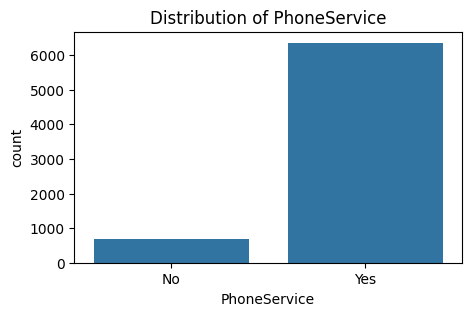

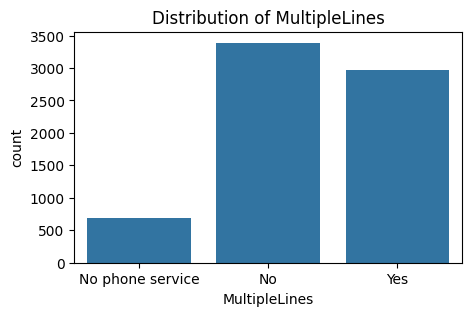

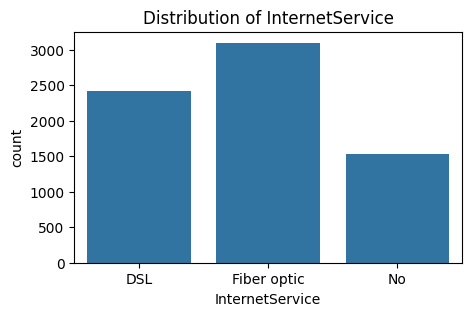

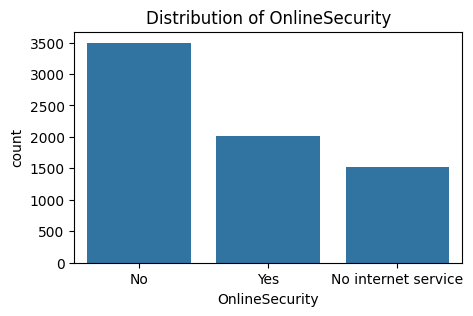

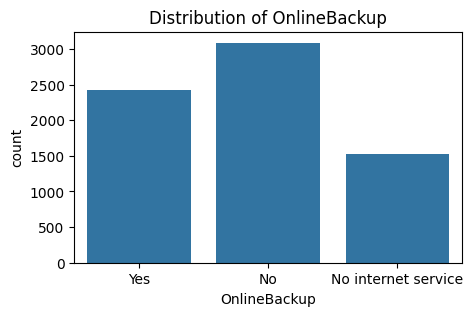

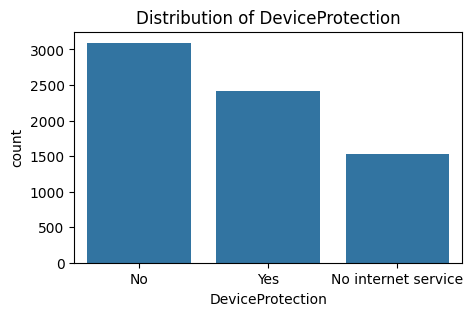

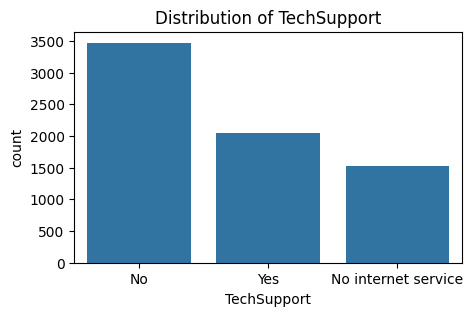

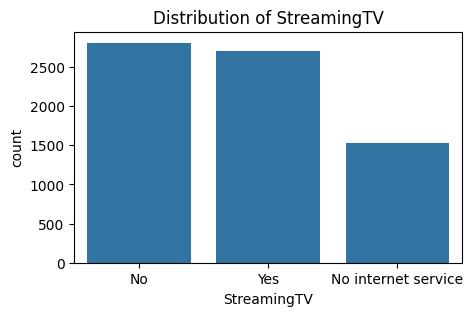

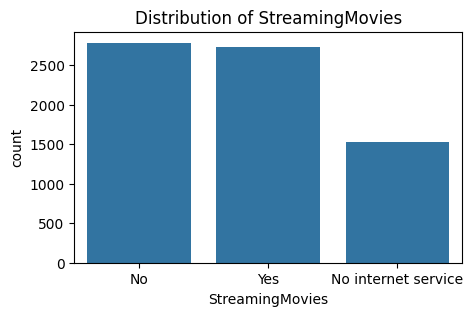

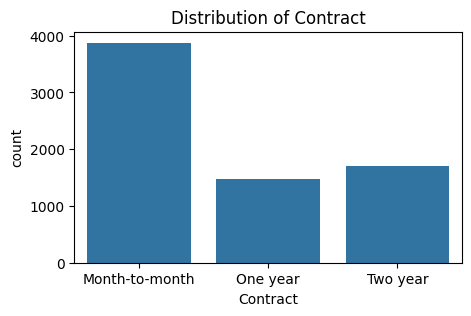

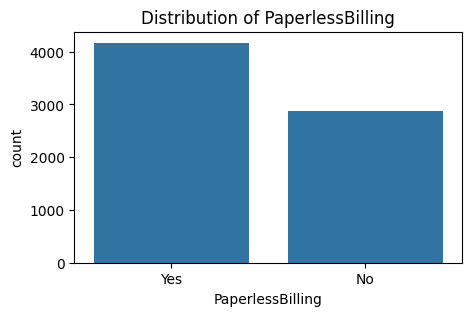

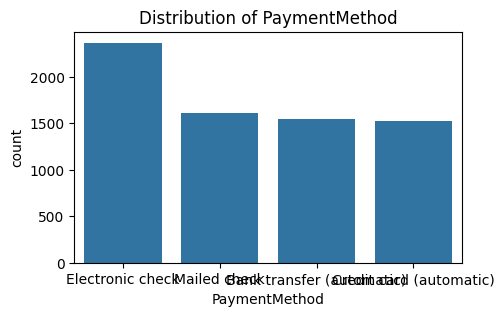

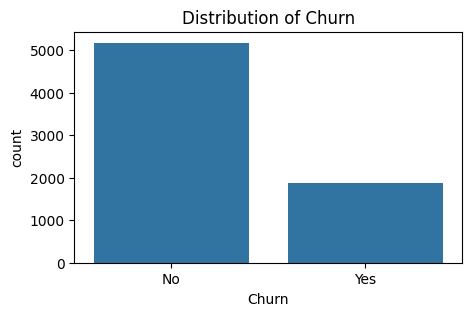

In [100]:
object_cols=df.select_dtypes(include="object").columns.to_list()
object_cols=["SeniorCitizen"]+object_cols

for cols in object_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=cols,data=df)
    plt.title(f"Distribution of {cols}")
    plt.show()

# 5. DATA PREPROCESSING


Label encoding of target coulmn

In [101]:
# The fact that the model does'nt gets objects datatype, hence there is a need to do label encoding.
df["Churn"]=df["Churn"].replace({"Yes":1,"No":0})

/tmp/ipykernel_2326/3610101417.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"]=df["Churn"].replace({"Yes":1,"No":0})


In [102]:
# Same needs to be done for all the columns

In [103]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Label encoding of categorical feature

In [104]:
# columns with object datatype
object_cols=df.select_dtypes(include="object").columns
object_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [105]:
# initialize dictionary to save the encoders
encoders={}

#apply label encoding to all the columns
for column in object_cols:
  label_encoder=LabelEncoder()
  df[column]=label_encoder.fit_transform(df[column])
  encoders[column]=label_encoder

#save the encoders to a pickle file
with open("encoders.pkl","wb") as file:
  pickle.dump(encoders,file)

In [106]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [107]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


**Training and Test data split**

In [108]:
#Splitting feature and target
X=df.drop(columns=["Churn"])
y=df["Churn"]

In [109]:
# Split ttraining and test data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [110]:
print(y_train.shape)

(5634,)


In [111]:
print(y_train.value_counts())  # WE CAN STILL SEE THAT THERE IS IMBALANCE IN THE DATASET. NOW SMOTE NEEDS TO BE PERFORMED TO MAKE IT BALANCED

Churn
0    4138
1    1496
Name: count, dtype: int64


Synthetic Minority Oversampling Technique (SMOTE)

In [112]:
smote=SMOTE(random_state=42)

In [113]:
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)

In [114]:
print(y_train_smote.shape)

(8276,)


In [115]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


In [116]:
# Now we can finaly see that there are as many 1s as 0s. Therefore the training dataset now is balanced

# 6. Model Training

Training with default Hyperparameters

In [117]:
# Dictionary of model
models={
    "DecisionTree":DecisionTreeClassifier(random_state=42),
    "RandomForest":RandomForestClassifier(random_state=42),
    "XGB":XGBRFClassifier(random_state=42)
}

In [118]:
# Dictionary to store the cross validation Scores
cv_scores={}

#Perform 5-fold cross validation for each model
for model_name,model in models.items():
  print(f"Training {model_name} with default parameters")
  scores=cross_val_score(model,X_train_smote,y_train_smote,cv=5,scoring="accuracy")
  cv_scores[model_name]=scores
  print(f"{model_name} cross-validation accuracy : {np.mean(scores):.2f}")
  print("-"*70)


  # RANDOM FOREST GIVES THE HIGHEST ACCURACY AS COMPARED TO OTHER MODELS WITH DEFAULT PARAMETERS

Training DecisionTree with default parameters
DecisionTree cross-validation accuracy : 0.78
----------------------------------------------------------------------
Training RandomForest with default parameters
RandomForest cross-validation accuracy : 0.84
----------------------------------------------------------------------
Training XGB with default parameters
XGB cross-validation accuracy : 0.81
----------------------------------------------------------------------


In [119]:
cv_scores

{'DecisionTree': array([0.68297101, 0.71299094, 0.82175227, 0.83564955, 0.83564955]),
 'RandomForest': array([0.72524155, 0.77824773, 0.90513595, 0.89425982, 0.90090634]),
 'XGB': array([0.71799517, 0.77220544, 0.85498489, 0.83987915, 0.85135952])}

In [120]:
rfc=RandomForestClassifier(random_state=42)

In [121]:
rfc.fit(X_train_smote,y_train_smote)

RandomForestClassifier(random_state=42)

In [122]:
print(y_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


# 7. Model Evaluation

In [123]:
#evaluate on test data
y_test_pred=rfc.predict(X_test)

print("Accuracy score : \n", accuracy_score(y_test,y_test_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_test_pred))
print("Classification report : \n",classification_report(y_test,y_test_pred))

Accuracy score : 
 0.7785663591199432
Confusion Matrix: 
 [[878 158]
 [154 219]]
Classification report : 
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



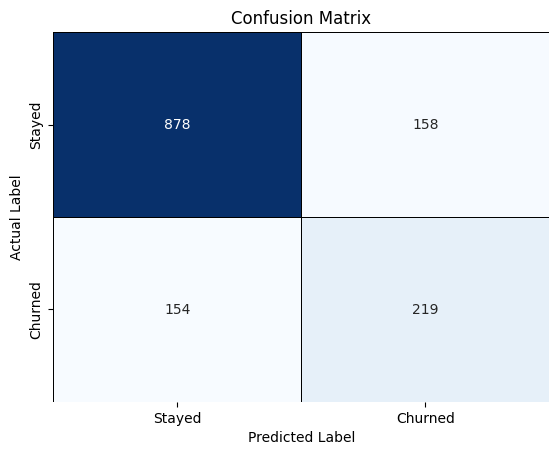

In [124]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            linewidths=0.5,
            linecolor='black',
            cbar=False,
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

**ROC Curve and AUC Score**

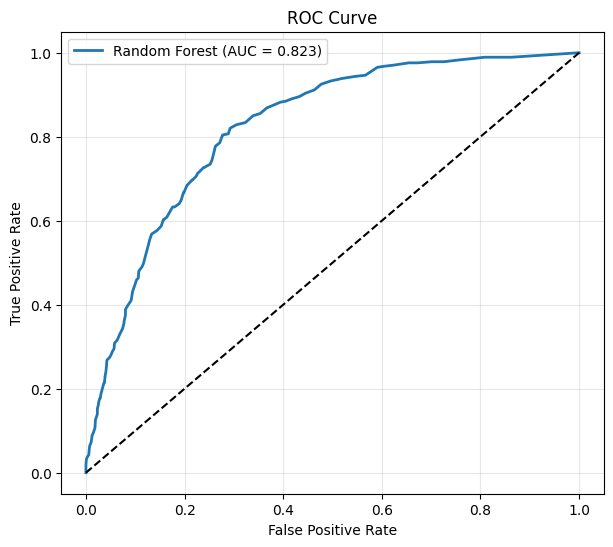

AUC Score: 0.823


In [125]:
# Predicted probabilities for class 1 (Churn = Yes)
y_prob = rfc.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         label=f'Random Forest (AUC = {auc_score:.3f})',
         linewidth=2)

# Random classifier line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("AUC Score:", round(auc_score,3))

The model is reasonably good at separating churn and non-churn customers. An AUC score of 0.823 indicates that the model captures meaningful patterns in the data and can be used to identify customers at risk of leaving.

In [126]:
# Save the trained model as puckle file
model_data={"model":rfc,"feature_names":X.columns.tolist()}


# Save the trained model into a pickle file
with open("customer_churn.pkl","wb") as file:
  pickle.dump(model_data,file)

# 8. Feature Importance

In [127]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rfc.feature_importances_
})

In [128]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)  # THis gives us top 10 important features

,Feature,Importance
18,TotalCharges,0.141563
17,MonthlyCharges,0.136518
14,Contract,0.126562
4,tenure,0.121823
8,OnlineSecurity,0.086714
11,TechSupport,0.073617
16,PaymentMethod,0.044333
9,OnlineBackup,0.038016
3,Dependents,0.030381
7,InternetService,0.030181


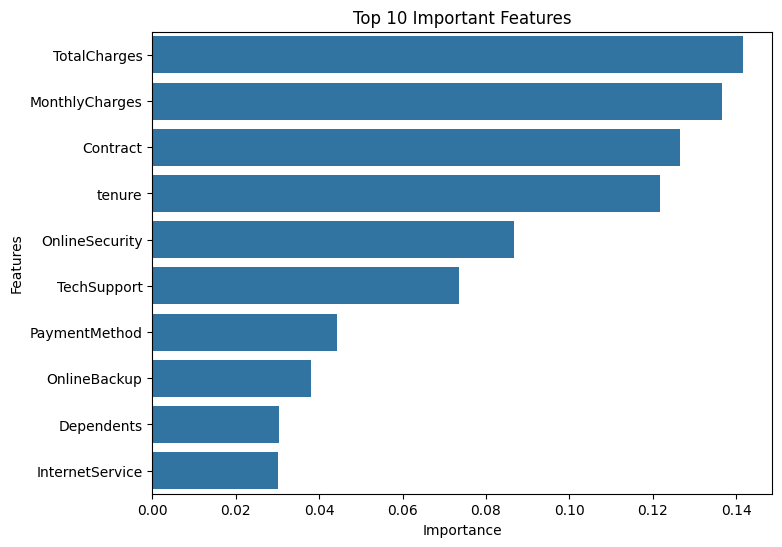

In [129]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

##  Observations

- **Total Charges** have the highest impact on churn prediction.
- Customers with higher **Monthly Charges** are more likely to churn.
- **Contract type** strongly affects customer retention.
- Customers with shorter **tenure** are more likely to leave.
- Having **Online Security** reduces churn.
- Having **Tech Support** improves customer retention.
- **Payment Method** also influences churn.
- **Online Backup**, **Dependents**, and **Internet Service** have relatively smaller effects.

##  Key Takeaways

- Billing and pricing are major factors behind churn.
- Long-term customers are more loyal.
- Value-added services help retain customers.
- Multiple factors together influence customer churn.

# 9. Buisness Insights

In [130]:
# Having a look at he few featuresand churn due to them

# Relation between Total Charges and Churn

In [131]:
pd.crosstab(
    pd.qcut(df['TotalCharges'],4),
    df['Churn'],
    normalize='index'
)*100

Churn,0,1
TotalCharges,,
"(-0.001, 398.55]",56.753689,43.246311
"(398.55, 1394.55]",74.602273,25.397727
"(1394.55, 3786.6]",76.988636,23.011364
"(3786.6, 8684.8]",85.519591,14.480409


# Relation between Monthly Charges and Churn


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

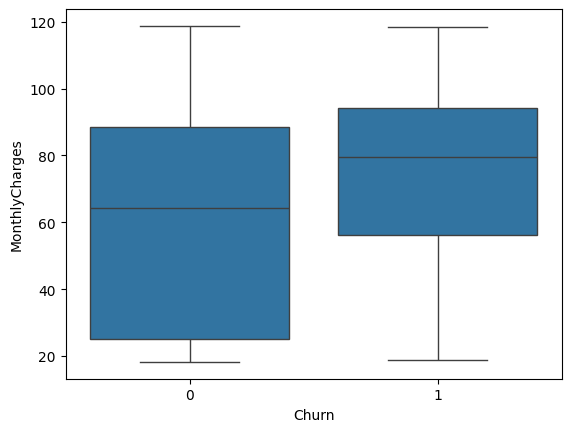

In [132]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

# Relation between Contract type and Churn

In [133]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

Churn,0,1
Contract,,
0,57.290323,42.709677
1,88.730482,11.269518
2,97.168142,2.831858


# Relation between Tenure and Churn

In [134]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
0,37.569965
1,17.979133


##  Business Insights

- Customers with **month-to-month contracts** have the highest churn rate, while long-term contracts significantly improve retention.
- Customers with **shorter tenure** are more likely to leave, indicating that churn is concentrated among new customers.
- Customers with **higher monthly charges** show a greater tendency to churn, suggesting that pricing influences customer satisfaction.
- Customers with **low total charges** have the highest churn rate, which indicates that many customers leave early before generating substantial revenue.
- Customers with **higher total charges** are more loyal, as they have stayed with the company for longer periods.

##  Recommendations

- Encourage customers to switch from month-to-month plans to long-term contracts through discounts and loyalty benefits.
- Focus on retaining new customers by improving onboarding and customer support during the initial months.
- Offer personalized discounts or better value plans to customers with high monthly charges.
- Identify customers with low total charges and proactively engage them with targeted retention campaigns.
- Use the churn prediction model to detect at-risk customers early and take preventive actions to reduce customer loss.

# 10. Load the saved model and build a Predictive system

In [135]:
#Load the saved model and the feature names
with open("customer_churn.pkl","rb") as f:
  model_data=pickle.load(f)

loaded_model=model_data["model"]
feature_names=model_data["feature_names"]

In [136]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [137]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [138]:
input_data = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 34,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "No",
    "DeviceProtection": "Yes",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "One year",
    "PaperlessBilling": "No",
    "PaymentMethod": "Mailed check",
    "MonthlyCharges": 56.95,
    "TotalCharges": 1889.5
}

input_data_df=pd.DataFrame([input_data])

with open("encoders.pkl","rb") as file:
  encoders=pickle.load(file)

#encode the categorical features using the saved encoders
for column, encoder in encoders.items():
  input_data_df[column]=encoder.transform(input_data_df[column])

# make a prediction
prediction=loaded_model.predict(input_data_df)
pred_prob=loaded_model.predict_proba(input_data_df)

print(prediction)

# Results
print(f"Prediction : {'Churn' if prediction[0]==1 else 'No Churn'}")
print(f"Prediction Probablity : {pred_prob}")

[0]
Prediction : No Churn
Prediction Probablity : [[1. 0.]]


**To do**
1. Implement hyperparameter Tuining
2. Try Model Selection
3. Try Downsampling
4. Try addressing oversampling
5. Try stratified K fold cv
